1. Imports

In [64]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import os
import time

2. Device setup

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

Device: cpu
Using CPU


3. Dataset and DataLoaders

In [65]:
train_dir = r"D:\deep learning project\data\intel image classification\seg_train\seg_train"
test_dir = r"D:\deep learning project\data\intel image classification\seg_test\seg_test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

full_dataset = datasets.ImageFolder(
    train_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=transform
)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Training: 11227
Validation: 2807
Test: 3000


4. Custom CNN architecture 


In [74]:
model = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Conv2d(128, 256, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2),

    nn.Flatten(),

    nn.Linear(256 * 14 * 14, 256),
    nn.ReLU(),
    nn.Dropout(0.5),

    nn.Linear(256, 6)
).to(device)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 13235270
Trainable parameters: 13235270


5. Model sanity check

In [75]:
images, labels = next(iter(train_loader))

outputs = model(images.to(device))

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 224, 224])
Output shape: torch.Size([32, 6])


6. Training setup


In [20]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

EPOCHS = 5

print("Training setup ready.")
print("Epochs:", EPOCHS)
print("Learning rate:", 0.001)

Training setup ready.
Epochs: 5
Learning rate: 0.001


7. Create models folder


In [22]:
import os

os.makedirs(r"D:\deep learning project\results\models", exist_ok=True)

print("Models folder is ready!")

Models folder is ready!


8. Training + validation

In [23]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_accuracy = 0.0

print("Starting training...")
print("Device:", device)

for epoch in range(EPOCHS):

    start_time = time.time()

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total

    # Store results
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # Save best model
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            r"D:\deep learning project\results\models\custom_cnn_best.pth"
        )

    elapsed_time = time.time() - start_time

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_accuracy:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_accuracy:.2f}% "
        f"| Time: {elapsed_time/60:.1f} min"
    )

print("\nTraining complete.")
print(f"Best validation accuracy: {best_val_accuracy:.2f}%")

Starting training...
Device: cpu
Epoch [1/5] | Train Loss: 0.8131 | Train Acc: 68.89% | Val Loss: 0.6618 | Val Acc: 75.42% | Time: 8.4 min
Epoch [2/5] | Train Loss: 0.6606 | Train Acc: 75.71% | Val Loss: 0.5871 | Val Acc: 78.77% | Time: 8.4 min
Epoch [3/5] | Train Loss: 0.5783 | Train Acc: 79.46% | Val Loss: 0.5753 | Val Acc: 79.48% | Time: 8.8 min
Epoch [4/5] | Train Loss: 0.4995 | Train Acc: 82.04% | Val Loss: 0.5759 | Val Acc: 78.30% | Time: 17.2 min
Epoch [5/5] | Train Loss: 0.4457 | Train Acc: 84.17% | Val Loss: 0.5446 | Val Acc: 80.69% | Time: 26.7 min

Training complete.
Best validation accuracy: 80.69%


8. Test evaluation

In [24]:
# Load the best CNN model

model.load_state_dict(
    torch.load(
        r"D:\deep learning project\results\models\custom_cnn_best.pth",
        map_location=device
    )
)

model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Custom CNN Test Accuracy: {test_accuracy:.2f}%")

Custom CNN Test Accuracy: 80.30%


9. Accuracy graph

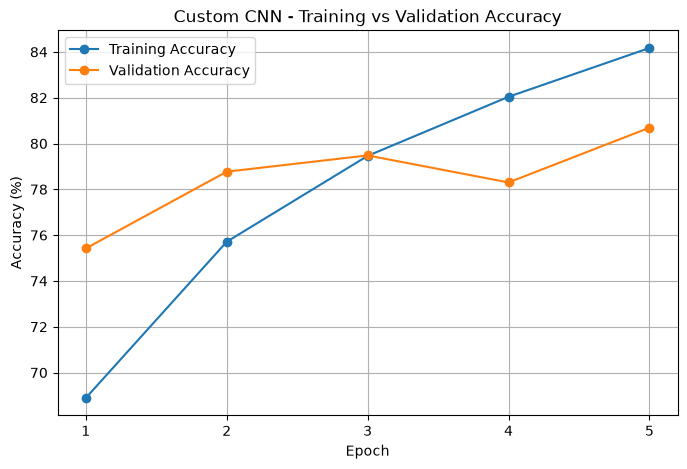

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracy,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Custom CNN - Training vs Validation Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.savefig(
    r"D:\deep learning project\results\plots\custom_cnn_accuracy.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

10. Loss graph

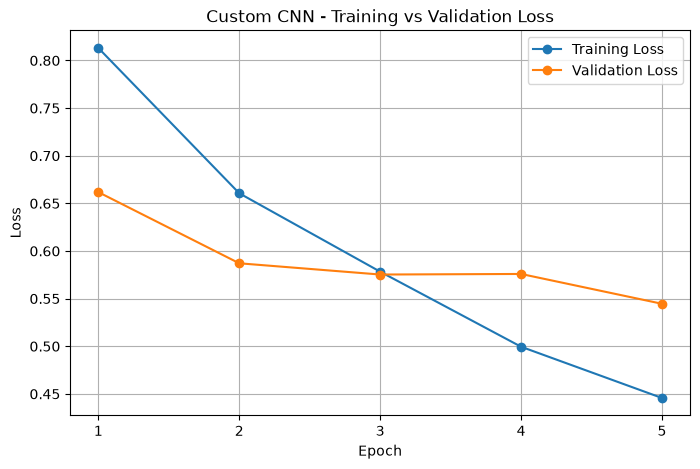

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN - Training vs Validation Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.savefig(
    r"D:\deep learning project\results\plots\custom_cnn_loss.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

11. Load the saved Custom CNN

In [79]:
from sklearn.metrics import accuracy_score, classification_report

# Create an empty PyTorch module
custom_test_model = nn.Module()

# Add the exact layers expected by the saved checkpoint
custom_test_model.conv1 = nn.Conv2d(3, 32, 3, padding=1)
custom_test_model.conv2 = nn.Conv2d(32, 64, 3, padding=1)
custom_test_model.conv3 = nn.Conv2d(64, 128, 3, padding=1)
custom_test_model.conv4 = nn.Conv2d(128, 256, 3, padding=1)

custom_test_model.pool = nn.MaxPool2d(2, 2)

custom_test_model.fc1 = nn.Linear(256 * 14 * 14, 256)
custom_test_model.dropout = nn.Dropout(0.5)
custom_test_model.fc2 = nn.Linear(256, 6)

custom_test_model = custom_test_model.to(device)


# Define the forward pass separately
def custom_cnn_forward(x):
    x = custom_test_model.pool(
        torch.relu(custom_test_model.conv1(x))
    )

    x = custom_test_model.pool(
        torch.relu(custom_test_model.conv2(x))
    )

    x = custom_test_model.pool(
        torch.relu(custom_test_model.conv3(x))
    )

    x = custom_test_model.pool(
        torch.relu(custom_test_model.conv4(x))
    )

    x = torch.flatten(x, 1)

    x = torch.relu(custom_test_model.fc1(x))
    x = custom_test_model.dropout(x)

    return custom_test_model.fc2(x)


# Load the saved Custom CNN
custom_cnn_path = r"D:\deep learning project\results\models\custom_cnn_best.pth"

state_dict = torch.load(
    custom_cnn_path,
    map_location=device
)

custom_test_model.load_state_dict(state_dict)

custom_test_model.eval()

print("Custom CNN checkpoint loaded successfully.")
print("Parameters:", sum(p.numel() for p in custom_test_model.parameters()))

Custom CNN checkpoint loaded successfully.
Parameters: 13235270


12. Final test evaluation

In [80]:
# Evaluate Custom CNN on the test set

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = custom_cnn_forward(images)
        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * accuracy_score(
    all_labels,
    all_predictions
)

print(f"Custom CNN Test Accuracy: {test_accuracy:.2f}%")
print(f"Test samples: {len(all_labels)}")

print("\nCustom CNN Classification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes,
        digits=4
    )
)

Custom CNN Test Accuracy: 80.30%
Test samples: 3000

Custom CNN Classification Report:
              precision    recall  f1-score   support

   buildings     0.7045    0.8513    0.7710       437
      forest     0.9833    0.8713    0.9239       474
     glacier     0.8390    0.7161    0.7727       553
    mountain     0.7472    0.7714    0.7591       525
         sea     0.7992    0.7961    0.7976       510
      street     0.7868    0.8323    0.8089       501

    accuracy                         0.8030      3000
   macro avg     0.8100    0.8064    0.8056      3000
weighted avg     0.8107    0.8030    0.8043      3000

